<a href="https://colab.research.google.com/github/brittanybee-alt/Python-Statistics-in-EDA---Brittany-Barrion-/blob/main/Frequentist_Inference_Case_Study_Part_B_%5BBrittany_Barrion%7D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts:
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions.

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset).

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('/content/insurance2.csv')

In [7]:
medical.shape

(1338, 8)

In [8]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

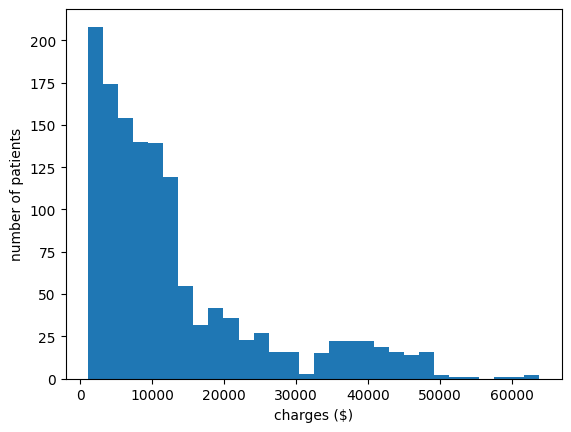

13270.422265141257 12110.011236693994


In [9]:
plt.hist(medical['charges'], bins=30)
plt.xlabel('charges ($)')
plt.ylabel('number of patients')
plt.show()

charges_mean = np.mean(medical['charges'])
charges_std = np.std(medical['charges'], ddof=1)
print(charges_mean, charges_std)

The histogram of charges is heavily right-skewed, not normally distributed — most charges cluster at the lower end, with a long tail of expensive outliers. The mean is 13,270.42 and the standard deviation is 12,110.01. Because the data is skewed rather than symmetric, the mean is pulled upward by the outliers and may not represent a 'typical' patient's charge well, and the standard deviation is unusually large relative to the mean, reflecting that spread. These stats are still useful for later analysis thanks to the CLT (which applies to the sampling distribution of the mean, not the raw data itself), but on their own they don't fully describe this data's shape.

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__. Because we're told to assume this is a random sample of hospital charges, and the sample size (n=1338) is large, the Central Limit Theorem tells us the sampling distribution of the mean will be approximately normal, even though the raw charges data itself is skewed. This justifies using frequentist inference to draw conclusions about the true population mean from this sample. Since we don't know the true population standard deviation and must estimate it from the sample, the appropriate test is a one-sample t-test, comparing the sample mean to the $12,000 threshold.

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__

In [10]:
n = len(medical['charges'])
degrees_freedom = n - 1

critical_t_one_sided = t.ppf(0.95, df=degrees_freedom)
print(critical_t_one_sided)

1.6459941145571317


In [11]:
margin_of_error = critical_t_one_sided * (charges_std / np.sqrt(n))
lower_bound = charges_mean - margin_of_error
print(lower_bound)

12725.48718381623


Since the administrator is only concerned about charges falling below $12,000 (a one-directional concern), a one-sided 95% confidence interval is appropriate. Using a one-sided critical t-value of 1.646 (df=1337), the calculated lower bound of the 95% confidence interval is $12,725.49. Since this is well above the $12,000 threshold, the administrator should not be concerned — the data suggests the true average charge remains comfortably above that critical level.

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*).

What assumption about the variances of the two groups are we making here?

__A:__. The null hypothesis (H₀) is that there is no difference in the average charges between insured and uninsured patients — their true population means are equal (μ_insured = μ_uninsured). The alternative hypothesis (H₁) is that there is a difference in average charges between the two groups — their true population means are not equal (μ_insured ≠ μ_uninsured).

The pooled standard deviation formula assumes that the two groups have equal population variances. By combining both groups' variances into a single shared value (s_p), the formula treats the underlying spread of charges as if it's the same for both the insured and uninsured populations, rather than allowing each group to have its own distinct variance.

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__

In [12]:
insured = medical[medical['insuranceclaim'] == 1]['charges']
uninsured = medical[medical['insuranceclaim'] == 0]['charges']

n0 = len(insured)
n1 = len(uninsured)
mean0 = np.mean(insured)
mean1 = np.mean(uninsured)
std0 = np.std(insured, ddof=1)
std1 = np.std(uninsured, ddof=1)

print(n0, mean0, std0)
print(n1, mean1, std1)

783 16423.928276537677 14045.928418802127
555 8821.421892306305 6446.510126811736


In [13]:
sp = np.sqrt(((n0 - 1) * std0**2 + (n1 - 1) * std1**2) / (n0 + n1 - 2))
print(sp)

11520.034268775256


In [14]:
t_stat_manual = (mean0 - mean1) / (sp * np.sqrt(1/n0 + 1/n1))
print(t_stat_manual)

11.893299030876715


In [15]:
df = n0 + n1 - 2
p_value_manual = 2 * (1 - t.cdf(abs(t_stat_manual), df))
print(p_value_manual)

0.0


In [16]:
print(f"{p_value_manual:.2e}")

0.00e+00


In [17]:
from scipy.stats import ttest_ind

t_stat_scipy, p_value_scipy = ttest_ind(insured, uninsured)
print(t_stat_scipy, p_value_scipy)

11.893299030876712 4.461230231620717e-31


Using the manual formulas, the pooled standard deviation was 11,520.03, giving a t-statistic of 11.89 and a p-value of approximately 4.46 × 10⁻³¹. Using scipy's ttest_ind() function on the same two groups gave a t-statistic of 11.89 and a p-value of 4.46 × 10⁻³¹ — an exact match with the manual calculation. This extremely small p-value provides strong evidence against the null hypothesis, indicating that insured and uninsured patients are charged significantly different amounts.

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__. Looking through scipy.stats documentation, there isn't a dedicated one-sample z-test function equivalent to ttest_1samp(). This makes sense because a z-test requires knowing the true population standard deviation, which is rarely known in real-world data — we almost always have to estimate it from a sample instead, which is exactly what calls for a t-test. The z-test is more of a theoretical/teaching tool (useful when population parameters are known, like in the simulated data from Part A) rather than something commonly applied to real datasets, which is likely why scipy doesn't provide a built-in function for it.

## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test